In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Import Dataset and Explore

In [2]:
DF = pd.read_csv(r'GeneratedHouseingData.csv')

In [3]:
DF.columns

Index(['ID', 'Price', 'SquareFootage', 'NumBathrooms', 'NumBedrooms',
       'BackyardSpace', 'CrimeRate', 'SchoolRating', 'AgeOfHome',
       'DistanceToCityCenter', 'EmploymentRate', 'PropertyTaxRate',
       'RenovationQualityRate', 'LocalAmenities', 'TransportAccess',
       'Fireplace', 'HouseColor', 'Garage', 'Floors', 'Windows',
       'PreviousSalePrice', 'IsLuxury'],
      dtype='object')

In [4]:
DF.shape

(9000, 22)

In [5]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     9000 non-null   int64  
 1   Price                  9000 non-null   int64  
 2   SquareFootage          9000 non-null   int64  
 3   NumBathrooms           9000 non-null   int64  
 4   NumBedrooms            9000 non-null   int64  
 5   BackyardSpace          9000 non-null   int64  
 6   CrimeRate              9000 non-null   float64
 7   SchoolRating           9000 non-null   float64
 8   AgeOfHome              9000 non-null   int64  
 9   DistanceToCityCenter   9000 non-null   float64
 10  EmploymentRate         9000 non-null   float64
 11  PropertyTaxRate        9000 non-null   float64
 12  RenovationQualityRate  9000 non-null   int64  
 13  LocalAmenities         9000 non-null   int64  
 14  TransportAccess        9000 non-null   int64  
 15  Fire

In [6]:
DF.head()

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQualityRate,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,7,1159515,3128,2,1,1024,59.9,9.0,7,2.2,...,1,10,6,No,white,Yes,3,49,1158.4205,0
1,8,875266,2355,5,6,1167,18.3,7.4,3,13.3,...,3,1,3,No,white,Yes,2,11,83.0205,1
2,9,837353,1527,2,1,641,32.6,9.4,59,3.5,...,7,7,1,No,red,Yes,2,52,125.7705,1
3,11,731908,1530,4,1,655,7.3,9.6,14,12.4,...,1,6,10,No,red,Yes,2,50,969.3705,0
4,12,655974,1529,6,1,200,14.7,5.4,86,0.6,...,2,7,6,No,blue,Yes,3,47,832.5705,1


# Part B

In [7]:
#B1
DF2 = DF[['Price', 'SquareFootage', 'BackyardSpace', 'CrimeRate', 'SchoolRating', 'AgeOfHome',
       'DistanceToCityCenter', 'EmploymentRate', 'PropertyTaxRate',
       'Fireplace','Garage']].copy()

In [8]:
#B2
DF2.describe()

,Price,SquareFootage,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate
count,9.000000e+03,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,7.937131e+05,1912.355222,698.612556,28.580422,8.007900,24.050667,7.840367,92.880389,1.407806
std,1.624905e+05,685.722792,381.729528,15.984952,1.119265,22.643453,7.637134,3.371150,0.346287
min,2.467490e+05,700.000000,200.000000,0.300000,3.700000,0.000000,0.500000,80.400000,0.500000
25%,6.840670e+05,1421.000000,384.000000,16.100000,7.300000,7.000000,2.300000,90.600000,1.170000
50%,7.822160e+05,1797.500000,664.000000,26.600000,8.200000,17.000000,5.500000,93.000000,1.410000
75%,8.902662e+05,2279.250000,951.000000,39.125000,8.900000,34.000000,10.800000,95.300000,1.640000
max,1.463110e+06,4500.000000,2366.000000,87.000000,10.000000,100.000000,40.000000,99.000000,2.500000


In [9]:
#B2 cont. 
DF2.describe(include='object')

,Fireplace,Garage
count,9000,9000
unique,2,2
top,No,Yes
freq,5518,6001


In [10]:
DF2['Fireplace'].value_counts(normalize=True * 100)

No     0.613111
Yes    0.386889
Name: Fireplace, dtype: float64

In [11]:
DF2['Garage'].value_counts(normalize=True * 100)

Yes    0.666778
No     0.333222
Name: Garage, dtype: float64

In [12]:
#just for me, checking for non-null missing or inconsistent values
for col in DF2.columns:
    print(f"\n==={col}===")
    print(np.sort(DF2[col].unique()))


===Price===
[ 246749  282017  313808 ... 1451552 1454614 1463110]

===SquareFootage===
[ 700  706  712 ... 4474 4483 4500]

===BackyardSpace===
[ 200  201  202 ... 2244 2338 2366]

===CrimeRate===
[ 0.3  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4  1.5  1.6  1.7
  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8  2.9  3.   3.1
  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1  4.2  4.3  4.4  4.5
  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5  5.6  5.7  5.8  5.9
  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9  7.   7.1  7.2  7.3
  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3  8.4  8.5  8.6  8.7
  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7  9.8  9.9 10.  10.1
 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1 11.2 11.3 11.4 11.5
 11.6 11.7 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5 12.6 12.7 12.8 12.9
 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9 14.  14.1 14.2 14.3
 14.4 14.5 14.6 14.7 14.8 14.9 15.  15.1 15.2 15.3 15.4 15.5 15.6 15.7
 15.8 15.9 16.  16.1 

In [13]:
#B3
#Univariate Visuals - Qualitative - Box Plots

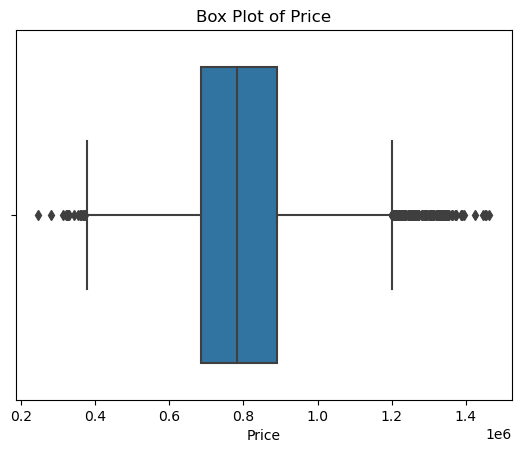

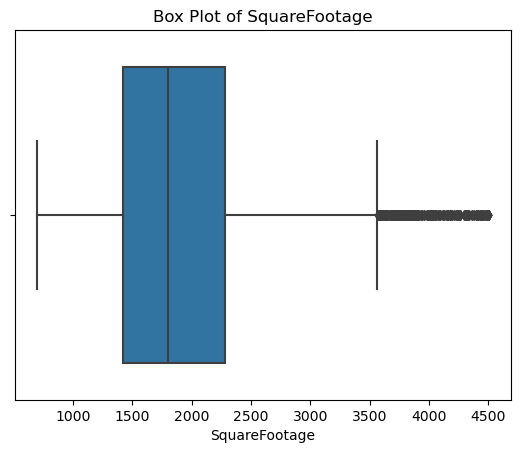

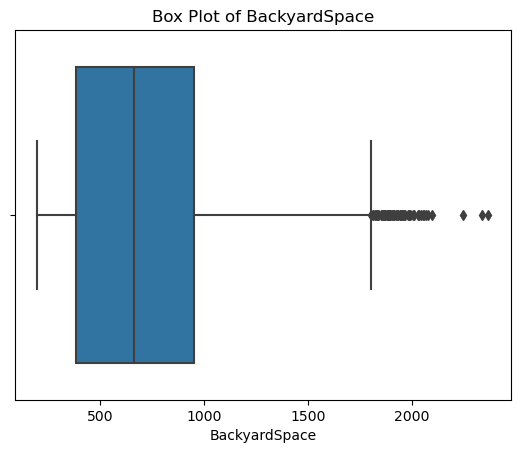

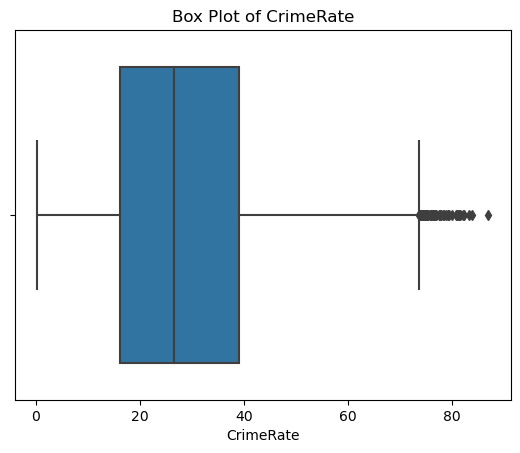

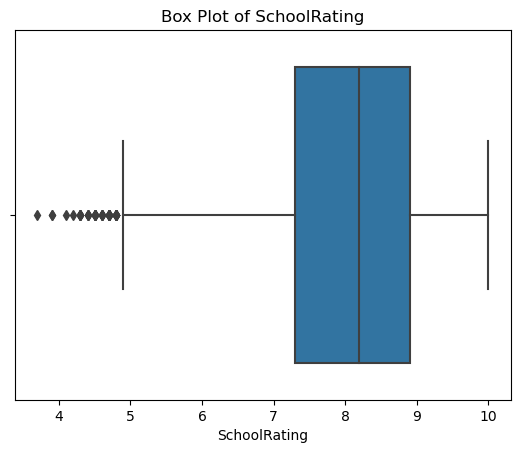

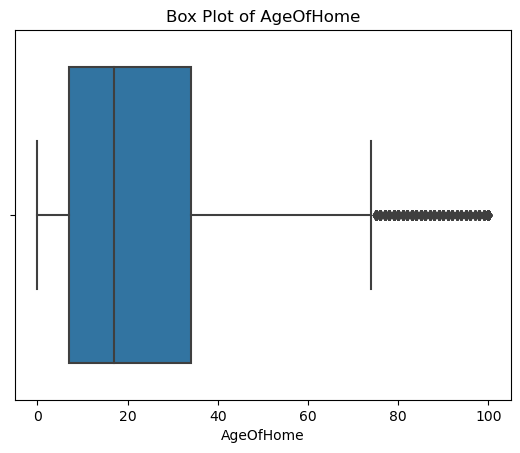

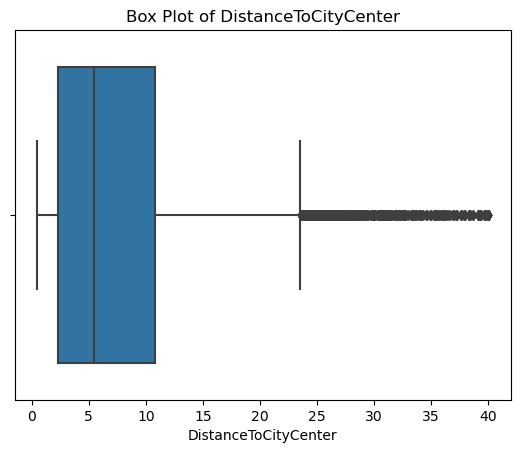

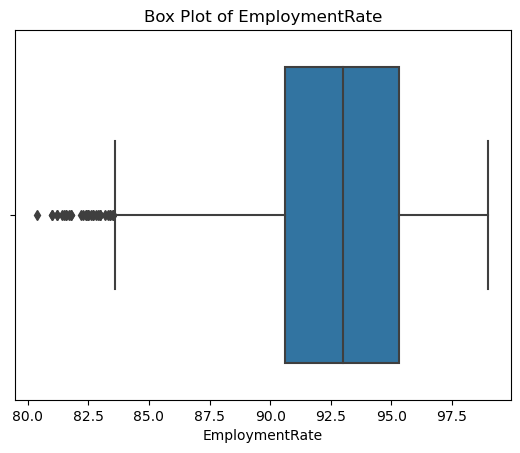

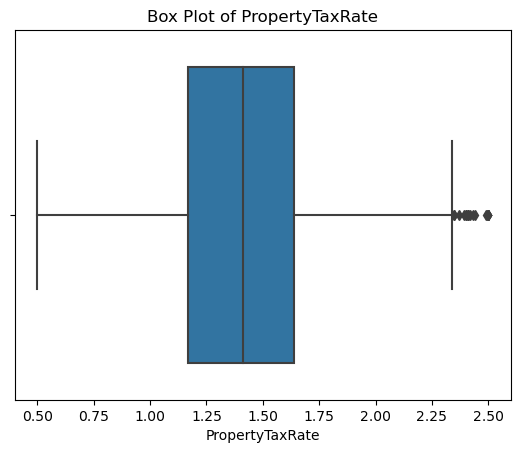

In [14]:
%matplotlib inline
for col in DF2.select_dtypes(include='number').columns:
    fig, ax = plt.subplots()
    sns.boxplot(x=DF[col], ax=ax)
    ax.set_title(f'Box Plot of {col}')
    plt.show()

In [15]:
#Univariate Visuals - Categorical - Bar Charts

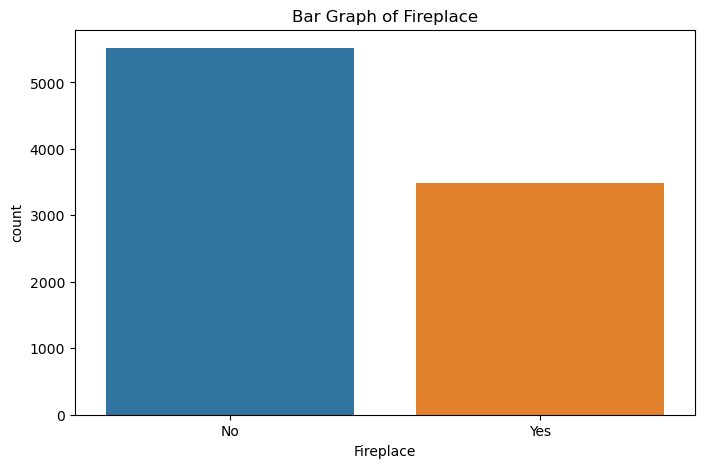

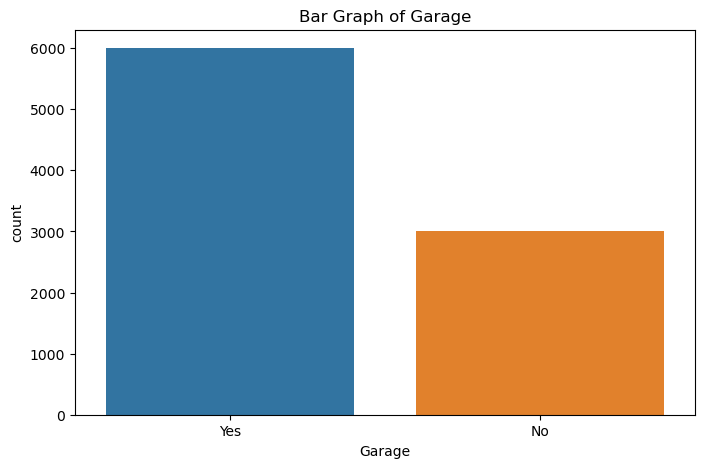

In [16]:
%matplotlib inline
for col in DF2.select_dtypes(include=['object', 'category', 'bool']).columns:
    fig, ax = plt.subplots(figsize=(8,5))
    sns.countplot(
        x=DF2[col],
        ax=ax
    )
    ax.set_title(f'Bar Graph of {col}')
    plt.show()

In [17]:
# Bivariate visuals - Continuous Qualitative - scatter plots

In [18]:
DF2.columns

Index(['Price', 'SquareFootage', 'BackyardSpace', 'CrimeRate', 'SchoolRating',
       'AgeOfHome', 'DistanceToCityCenter', 'EmploymentRate',
       'PropertyTaxRate', 'Fireplace', 'Garage'],
      dtype='object')

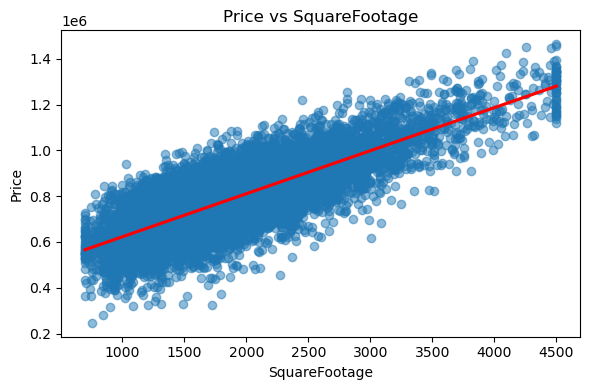

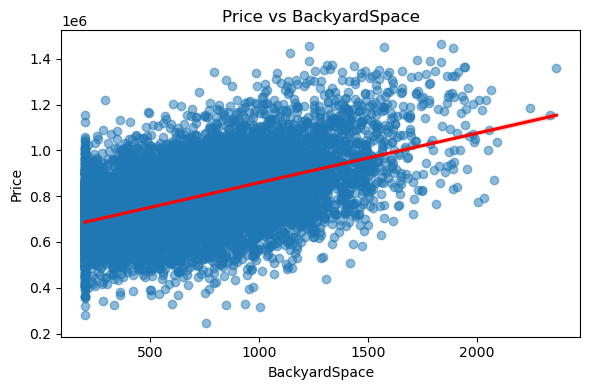

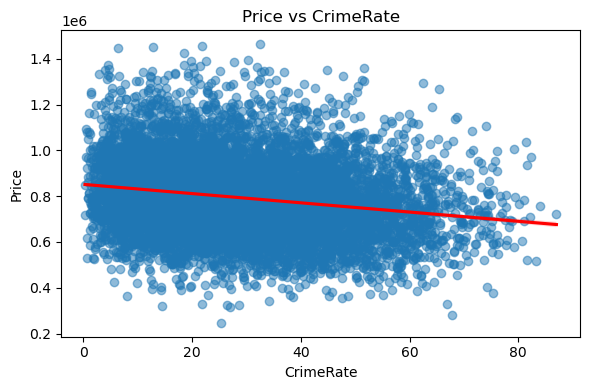

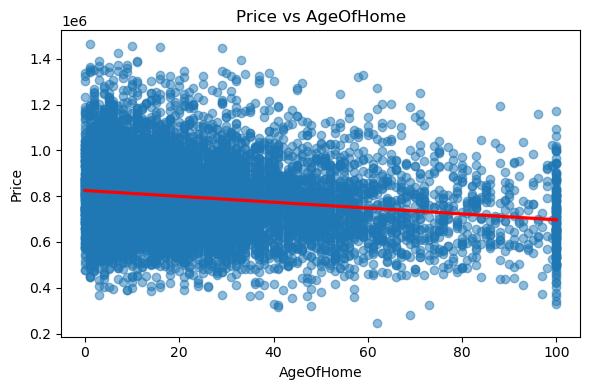

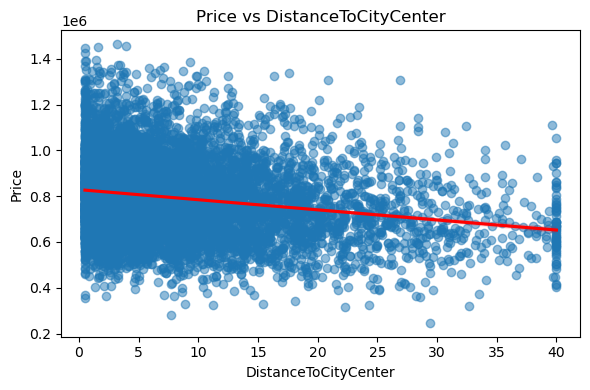

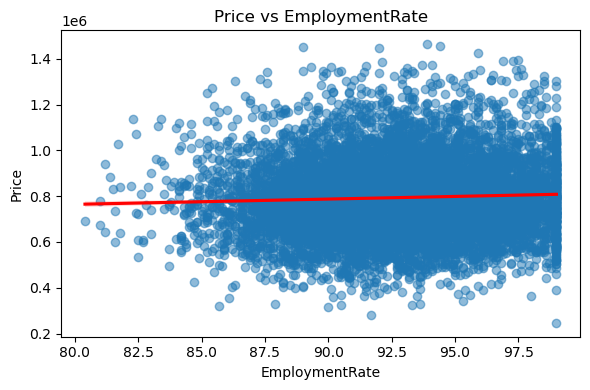

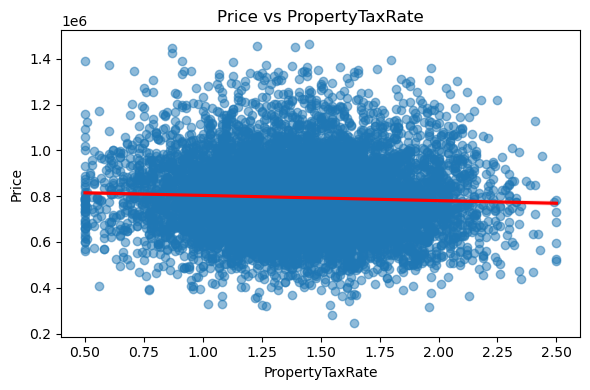

In [19]:
%matplotlib inline
#loop for bivariate scatter plot for all numeric variables except for dependent variable (price) and discrete variable (schoolrating)
numeric_cols = DF2[['SquareFootage', 'BackyardSpace', 'CrimeRate',
       'AgeOfHome', 'DistanceToCityCenter', 'EmploymentRate',
       'PropertyTaxRate']]
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(6,4))
    sns.regplot(
        x=DF2[col],
        y=DF2['Price'],
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red'},
        ax=ax
    )
    ax.set_title(f'Price vs {col}')
    plt.tight_layout()
    plt.show()

In [20]:
# Bivariate visuals - Categorical & Discrete Qualitative - stacked bar chart

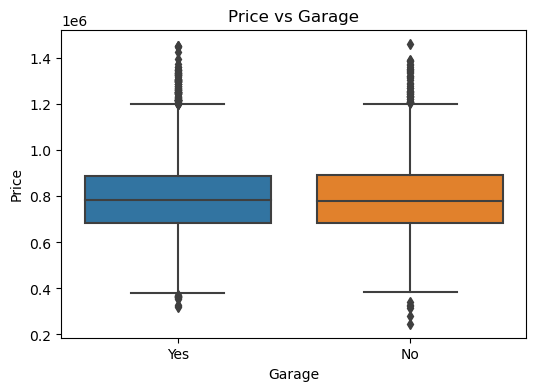

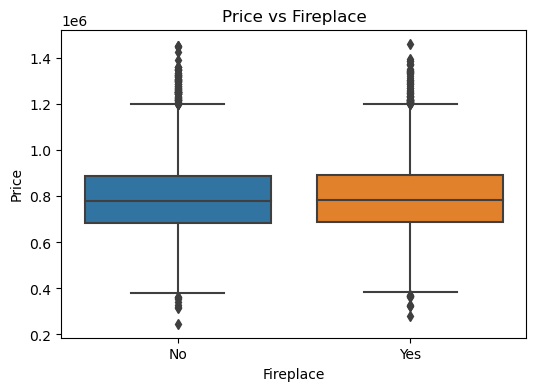

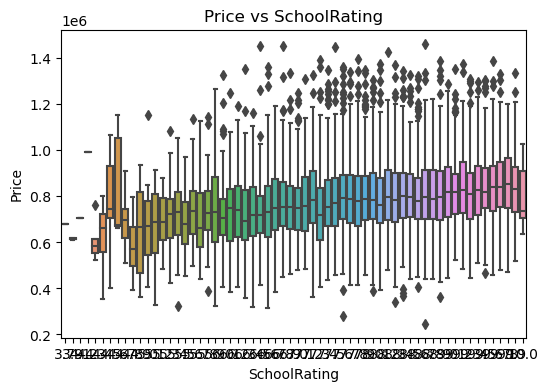

In [21]:
%matplotlib inline
categorical_discrete_vars = [
    'Garage',
    'Fireplace',
    'SchoolRating'
]
for col in categorical_discrete_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x=DF2[col],
        y=DF2['Price']
    )
    plt.title(f'Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.show()

# Encode and Clean Variables

In [22]:
#binary categories -- instead of using one hot encoding program & then dropping extra column to avoid dummy trap
#, just manually encoded
DF2['Garage_Encoded'] = np.where(DF2['Garage'] == 'Yes',1,0)
DF2['Fireplace_Encoded'] = np.where(DF2['Fireplace'] == 'Yes',1,0)

In [23]:
## double encoding of School Rating to bucket values in a more reasonable way that matches data dictionary

#===SchoolRating===
#[ 1  2  3  4  5  6  7  8  9 10]

DF2['SchoolRating_Text'] = np.where((DF2['SchoolRating'] > 0) & (DF2['SchoolRating'] < 5), 'BelowAverage','')
DF2['SchoolRating_Text'] = np.where((DF2['SchoolRating'] > 4) & (DF2['SchoolRating'] < 7), 'Average',DF2['SchoolRating_Text'])
DF2['SchoolRating_Text'] = np.where((DF2['SchoolRating'] > 6) & (DF2['SchoolRating'] < 11), 'AboveAverage',DF2['SchoolRating_Text'])

DF2['SchoolRating_Text'].unique()

array(['AboveAverage', 'Average', 'BelowAverage'], dtype=object)

In [24]:
DF2['SchoolRating_Encoded'] = np.where(DF2['SchoolRating_Text'] == 'BelowAverage',0,np.nan)
DF2['SchoolRating_Encoded'] = np.where(DF2['SchoolRating_Text'] =='Average',1,DF2['SchoolRating_Encoded'])
DF2['SchoolRating_Encoded'] = np.where(DF2['SchoolRating_Text'] == 'AboveAverage',2,DF2['SchoolRating_Encoded'])

DF2['SchoolRating_Encoded'].unique()

array([2., 1., 0.])

In [25]:
DF2.columns

Index(['Price', 'SquareFootage', 'BackyardSpace', 'CrimeRate', 'SchoolRating',
       'AgeOfHome', 'DistanceToCityCenter', 'EmploymentRate',
       'PropertyTaxRate', 'Fireplace', 'Garage', 'Garage_Encoded',
       'Fireplace_Encoded', 'SchoolRating_Text', 'SchoolRating_Encoded'],
      dtype='object')

Price: 164 outliers capped


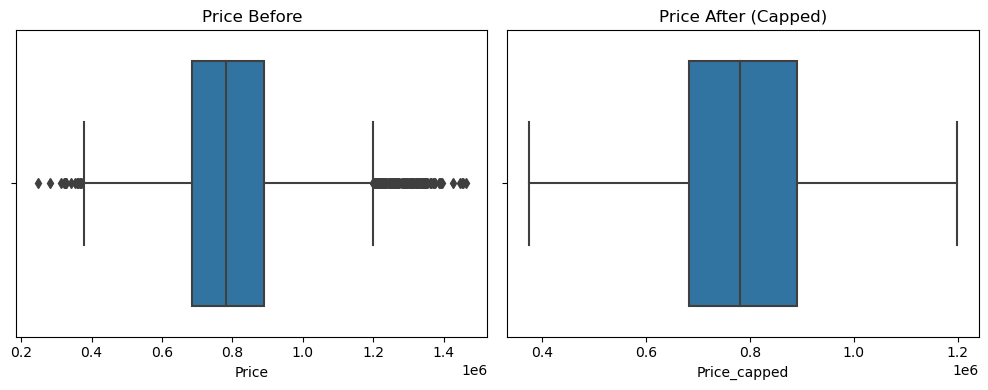

SquareFootage: 240 outliers capped


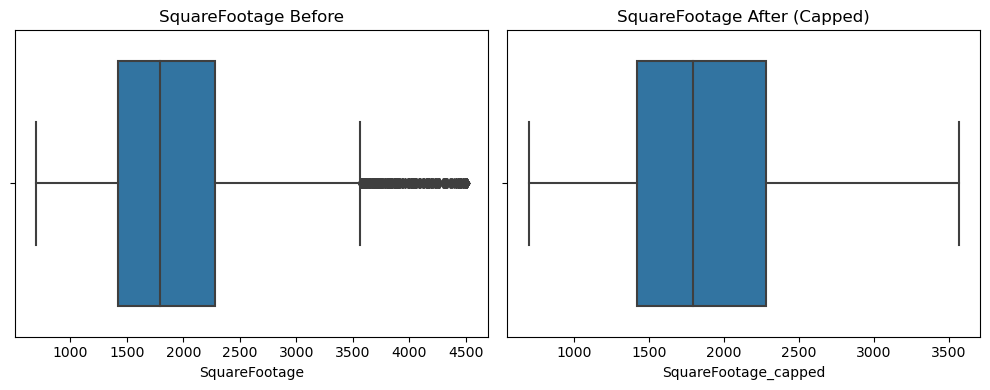

BackyardSpace: 59 outliers capped


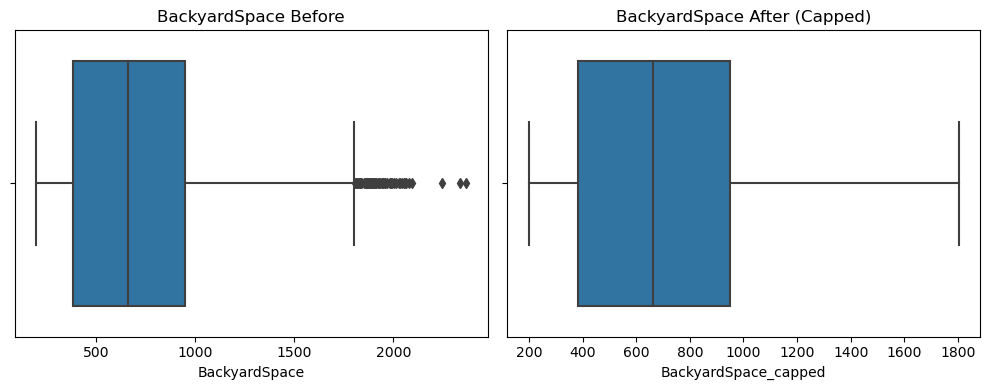

CrimeRate: 60 outliers capped


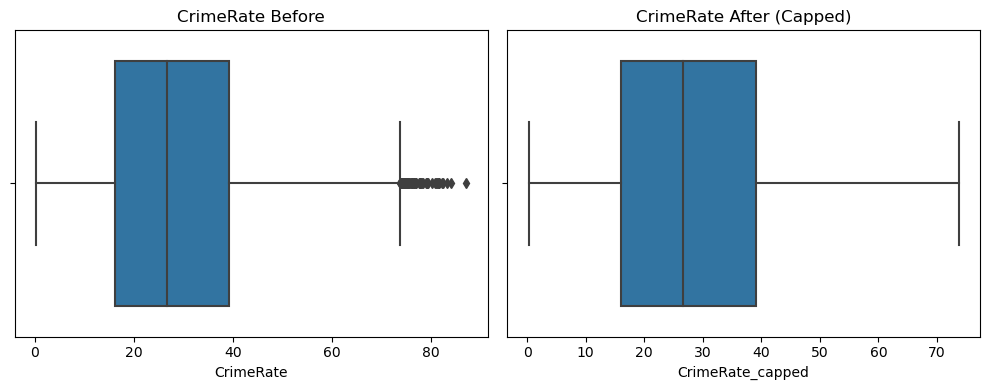

SchoolRating: 50 outliers capped


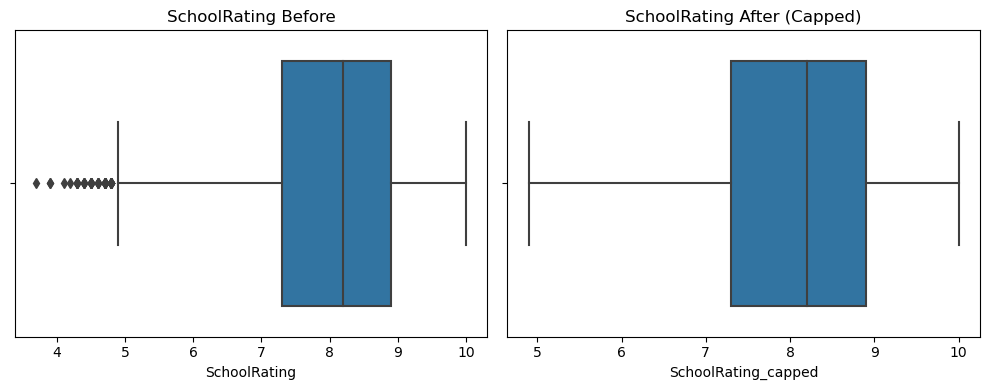

AgeOfHome: 419 outliers capped


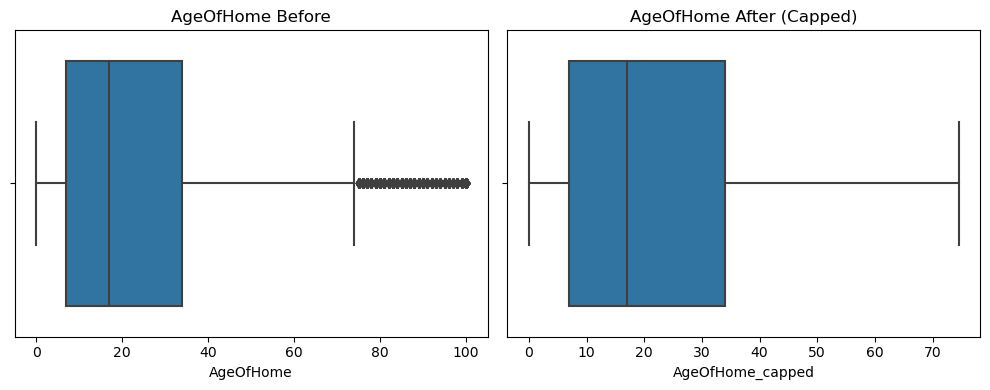

DistanceToCityCenter: 481 outliers capped


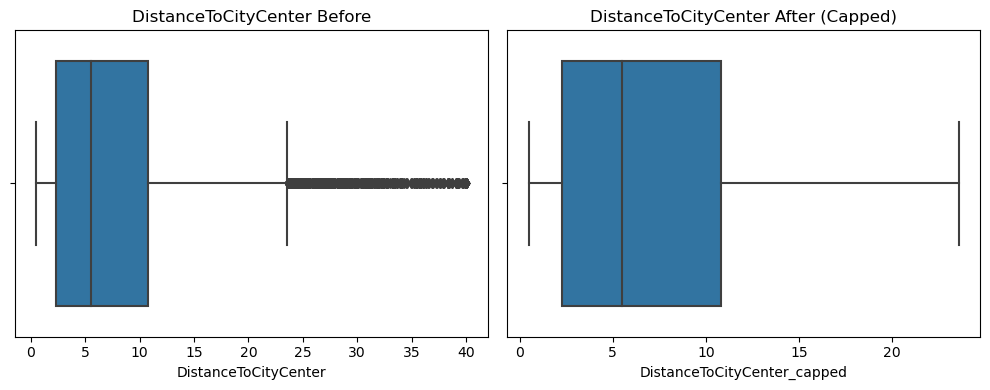

EmploymentRate: 34 outliers capped


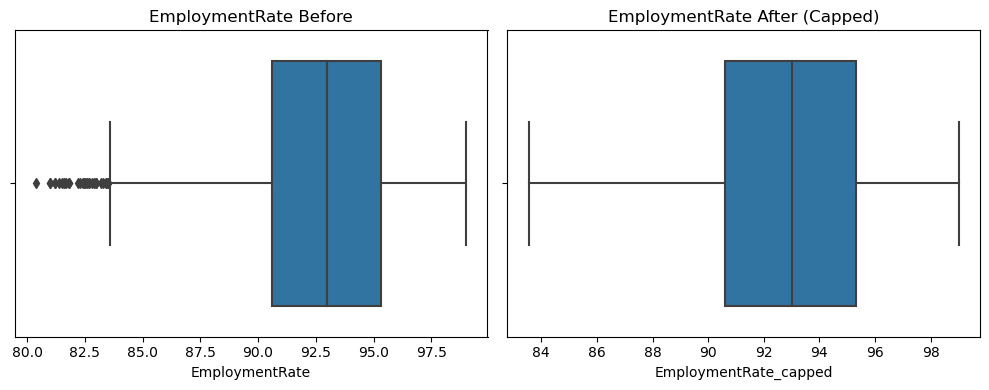

PropertyTaxRate: 20 outliers capped


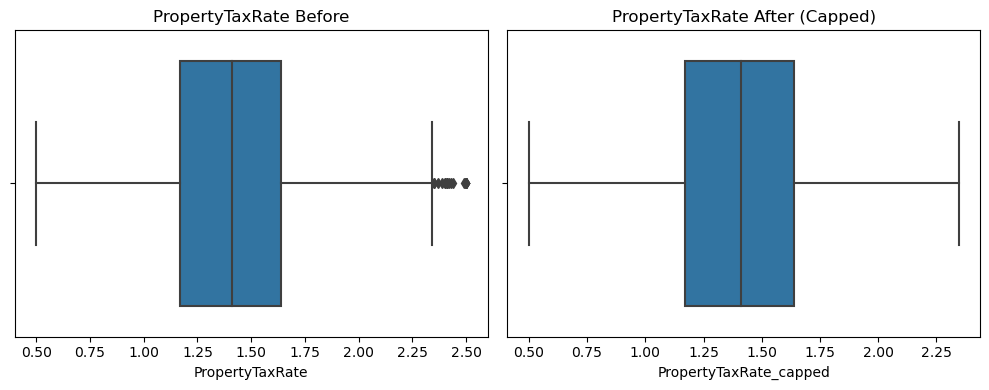

In [26]:
# define and cap the outliers found

variables = ['Price', 'SquareFootage', 'BackyardSpace', 'CrimeRate', 'SchoolRating',
       'AgeOfHome', 'DistanceToCityCenter', 'EmploymentRate',
       'PropertyTaxRate']

for var in variables:

    Q1 = DF2[var].quantile(0.25)
    Q3 = DF2[var].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    capped_col = f"{var}_capped"

    DF2[capped_col] = DF2[var].clip(
        lower=lower_bound,
        upper=upper_bound
    )


    num_capped = (
        (DF2[var] < lower_bound) |
        (DF2[var] > upper_bound)
    ).sum()

    plt.figure(figsize=(10,4))

    # before
    plt.subplot(1,2,1)

    sns.boxplot(x=DF2[var])

    plt.title(f'{var} Before')

    # after
    plt.subplot(1,2,2)

    sns.boxplot(x=DF2[capped_col])

    plt.title(f'{var} After (Capped)')

    plt.tight_layout()

    print(f"{var}: {num_capped} outliers capped")

    plt.show()

# Part C

In [27]:
DF2.columns

Index(['Price', 'SquareFootage', 'BackyardSpace', 'CrimeRate', 'SchoolRating',
       'AgeOfHome', 'DistanceToCityCenter', 'EmploymentRate',
       'PropertyTaxRate', 'Fireplace', 'Garage', 'Garage_Encoded',
       'Fireplace_Encoded', 'SchoolRating_Text', 'SchoolRating_Encoded',
       'Price_capped', 'SquareFootage_capped', 'BackyardSpace_capped',
       'CrimeRate_capped', 'SchoolRating_capped', 'AgeOfHome_capped',
       'DistanceToCityCenter_capped', 'EmploymentRate_capped',
       'PropertyTaxRate_capped'],
      dtype='object')

In [28]:
DF3 = DF2[['Price_capped', 'SquareFootage_capped', 'BackyardSpace_capped',
       'CrimeRate_capped', 'AgeOfHome_capped',
       'DistanceToCityCenter_capped', 'EmploymentRate_capped',
       'PropertyTaxRate_capped', 'SchoolRating_Encoded',
       'Fireplace_Encoded', 'Garage_Encoded']]

In [29]:
DF3.to_csv(r'Cleaned_Dataset.csv')

In [30]:
X = DF3.drop(columns=['Price_capped'])

y = DF3['Price_capped']

In [31]:
train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [32]:
train_X.to_csv(r'Training_Datset.csv')
test_X.to_csv(r'Testing_Dataset.csv')

In [33]:
train_df = train_X.copy()

train_df['Price_capped'] = train_y

In [34]:
predictors = train_df.columns.drop('Price_capped')

formula = 'Price_capped ~ ' + ' + '.join(predictors)

print(formula)

Price_capped ~ SquareFootage_capped + BackyardSpace_capped + CrimeRate_capped + AgeOfHome_capped + DistanceToCityCenter_capped + EmploymentRate_capped + PropertyTaxRate_capped + SchoolRating_Encoded + Fireplace_Encoded + Garage_Encoded


In [35]:
housing_lm = smf.ols(
    formula=formula,
    data=train_df
).fit()
print(housing_lm.summary())

                            OLS Regression Results                            
Dep. Variable:           Price_capped   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     2148.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:52:24   Log-Likelihood:                -91452.
No. Observations:                7200   AIC:                         1.829e+05
Df Residuals:                    7189   BIC:                         1.830e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

# C4: optimize model

In [36]:
# find where multicollinearity is coming from using variance inflation factor and correlation matrix

In [37]:
vif_data = pd.DataFrame()

vif_data["Feature"] = train_X.columns

vif_data["VIF"] = [
    variance_inflation_factor(train_X.values, i)
    for i in range(train_X.shape[1])
]

print(vif_data)

                       Feature        VIF
0         SquareFootage_capped  13.909357
1         BackyardSpace_capped   6.496036
2             CrimeRate_capped   4.232485
3             AgeOfHome_capped   2.281026
4  DistanceToCityCenter_capped   2.304030
5        EmploymentRate_capped  87.062293
6       PropertyTaxRate_capped  17.199604
7         SchoolRating_Encoded  59.773245
8            Fireplace_Encoded   1.785871
9               Garage_Encoded   3.312833


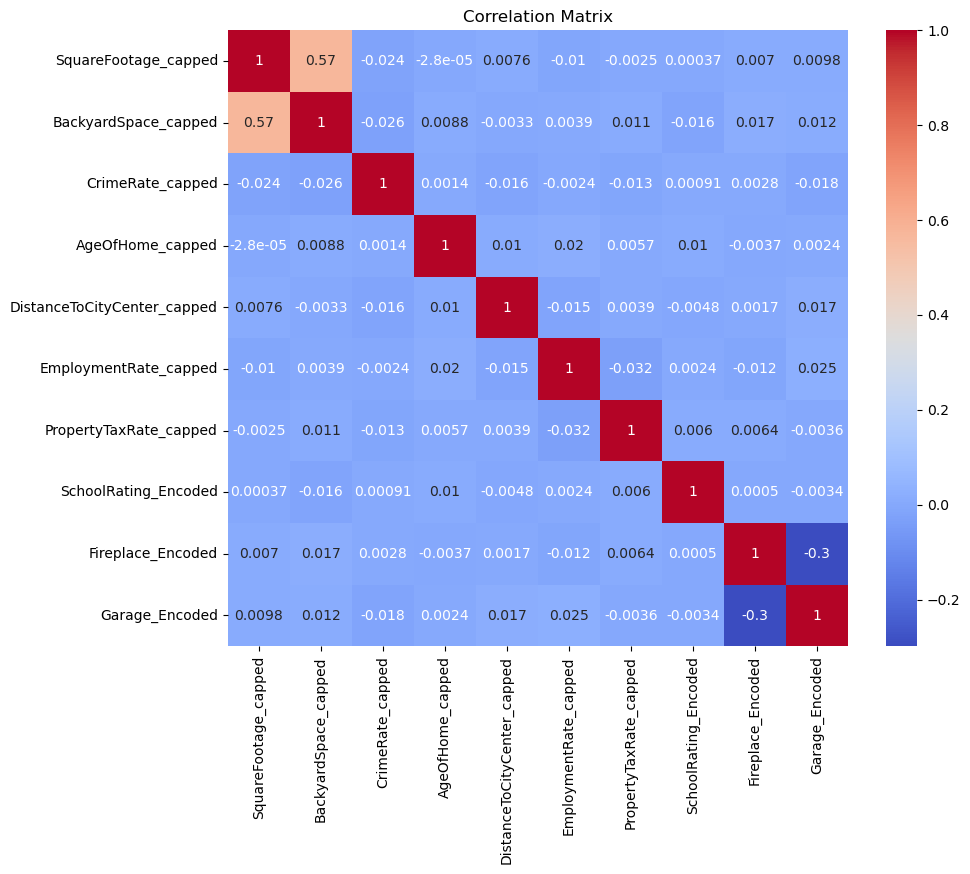

In [38]:
corr_matrix = train_X.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [39]:
## drop column Employment_Rate_Capped and re-run
X = X.drop(columns=['EmploymentRate_capped'])

train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

train_df = train_X.copy()
train_df['Price_capped'] = train_y

In [40]:
predictors = train_df.columns.drop('Price_capped')

formula = 'Price_capped ~ ' + ' + '.join(predictors)

housing_lm = smf.ols(
    formula=formula,
    data=train_df
).fit()

print(housing_lm.summary())

                            OLS Regression Results                            
Dep. Variable:           Price_capped   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     2357.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:52:41   Log-Likelihood:                -91487.
No. Observations:                7200   AIC:                         1.830e+05
Df Residuals:                    7190   BIC:                         1.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [41]:
vif_data = pd.DataFrame()

vif_data["Feature"] = train_X.columns

vif_data["VIF"] = [
    variance_inflation_factor(train_X.values, i)
    for i in range(train_X.shape[1])
]

print(vif_data)

                       Feature        VIF
0         SquareFootage_capped  13.315601
1         BackyardSpace_capped   6.488670
2             CrimeRate_capped   4.086630
3             AgeOfHome_capped   2.257132
4  DistanceToCityCenter_capped   2.279968
5       PropertyTaxRate_capped  14.744974
6         SchoolRating_Encoded  23.376194
7            Fireplace_Encoded   1.762636
8               Garage_Encoded   3.214119


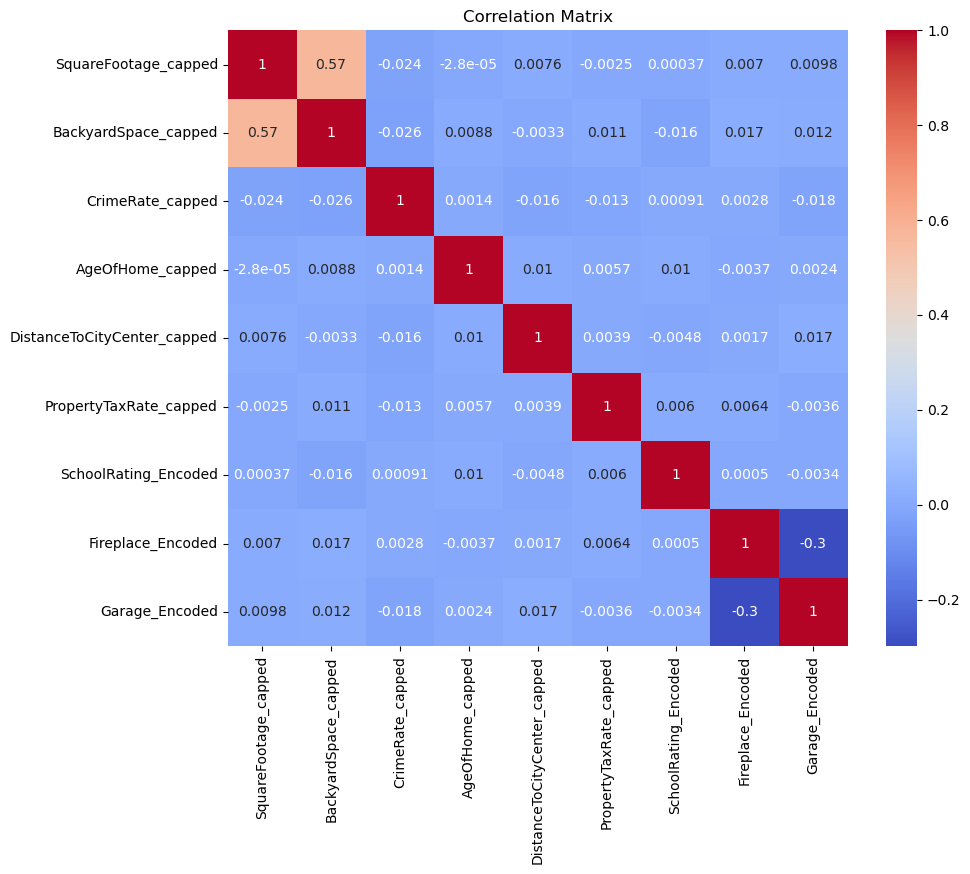

In [42]:
corr_matrix = train_X.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [43]:
## drop column SchoolRating_Encoded and re-run
X = X.drop(columns=['SchoolRating_Encoded'])

train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

train_df = train_X.copy()
train_df['Price_capped'] = train_y

In [44]:
predictors = train_df.columns.drop('Price_capped')

formula = 'Price_capped ~ ' + ' + '.join(predictors)

housing_lm = smf.ols(
    formula=formula,
    data=train_df
).fit()

print(housing_lm.summary())

                            OLS Regression Results                            
Dep. Variable:           Price_capped   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     2447.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:54:06   Log-Likelihood:                -91700.
No. Observations:                7200   AIC:                         1.834e+05
Df Residuals:                    7191   BIC:                         1.835e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [45]:
vif_data = pd.DataFrame()

vif_data["Feature"] = train_X.columns

vif_data["VIF"] = [
    variance_inflation_factor(train_X.values, i)
    for i in range(train_X.shape[1])
]

print(vif_data)

                       Feature        VIF
0         SquareFootage_capped  11.914397
1         BackyardSpace_capped   6.488177
2             CrimeRate_capped   3.793377
3             AgeOfHome_capped   2.204600
4  DistanceToCityCenter_capped   2.233068
5       PropertyTaxRate_capped   9.406594
6            Fireplace_Encoded   1.715524
7               Garage_Encoded   3.043500


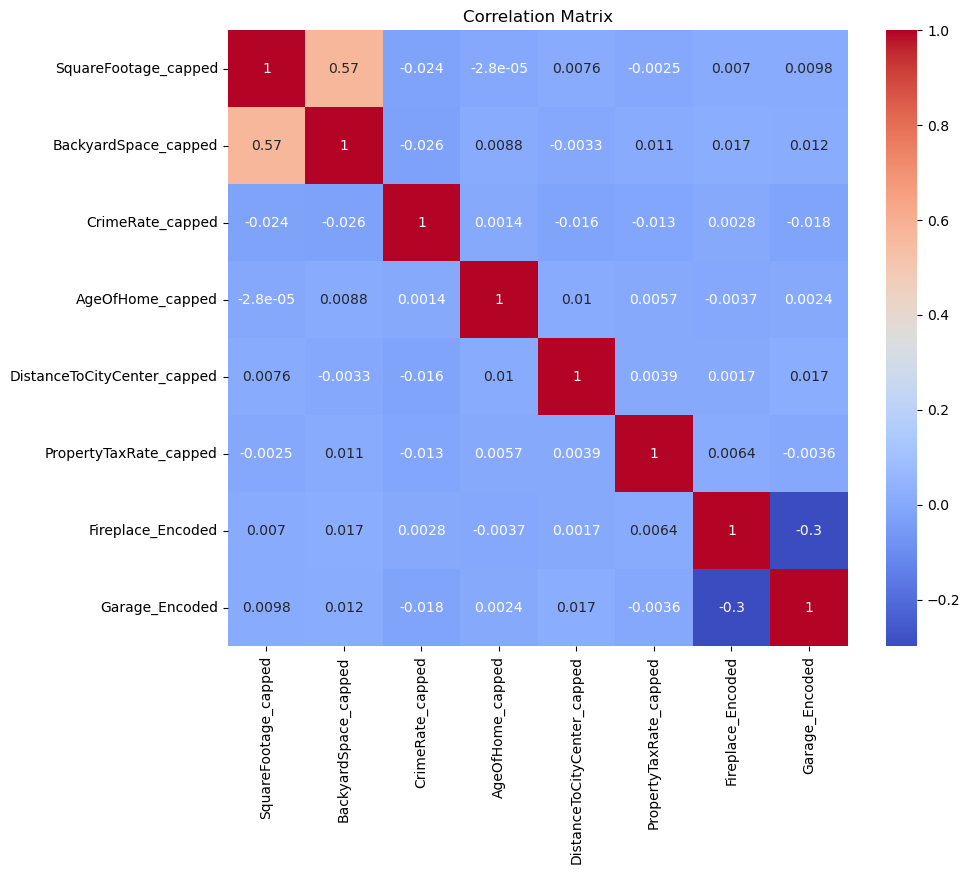

In [46]:
corr_matrix = train_X.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# drop SquareFootage_capped and re-run

In [50]:
X = X.drop(columns=['SquareFootage_capped'])

train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

train_df = train_X.copy()
train_df['Price_capped'] = train_y

In [51]:
predictors = train_df.columns.drop('Price_capped')

formula = 'Price_capped ~ ' + ' + '.join(predictors)

housing_lm = smf.ols(
    formula=formula,
    data=train_df
).fit()

print(housing_lm.summary())

                            OLS Regression Results                            
Dep. Variable:           Price_capped   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     675.8
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:57:23   Log-Likelihood:                -94823.
No. Observations:                7200   AIC:                         1.897e+05
Df Residuals:                    7193   BIC:                         1.897e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [52]:
vif_data = pd.DataFrame()

vif_data["Feature"] = train_X.columns

vif_data["VIF"] = [
    variance_inflation_factor(train_X.values, i)
    for i in range(train_X.shape[1])
]

print(vif_data)

                       Feature       VIF
0         BackyardSpace_capped  3.322825
1             CrimeRate_capped  3.156237
2             AgeOfHome_capped  2.081609
3  DistanceToCityCenter_capped  2.095980
4            Fireplace_Encoded  1.593161
5               Garage_Encoded  2.615820


In [ ]:
## no multicollinearity over 5, move on to next method

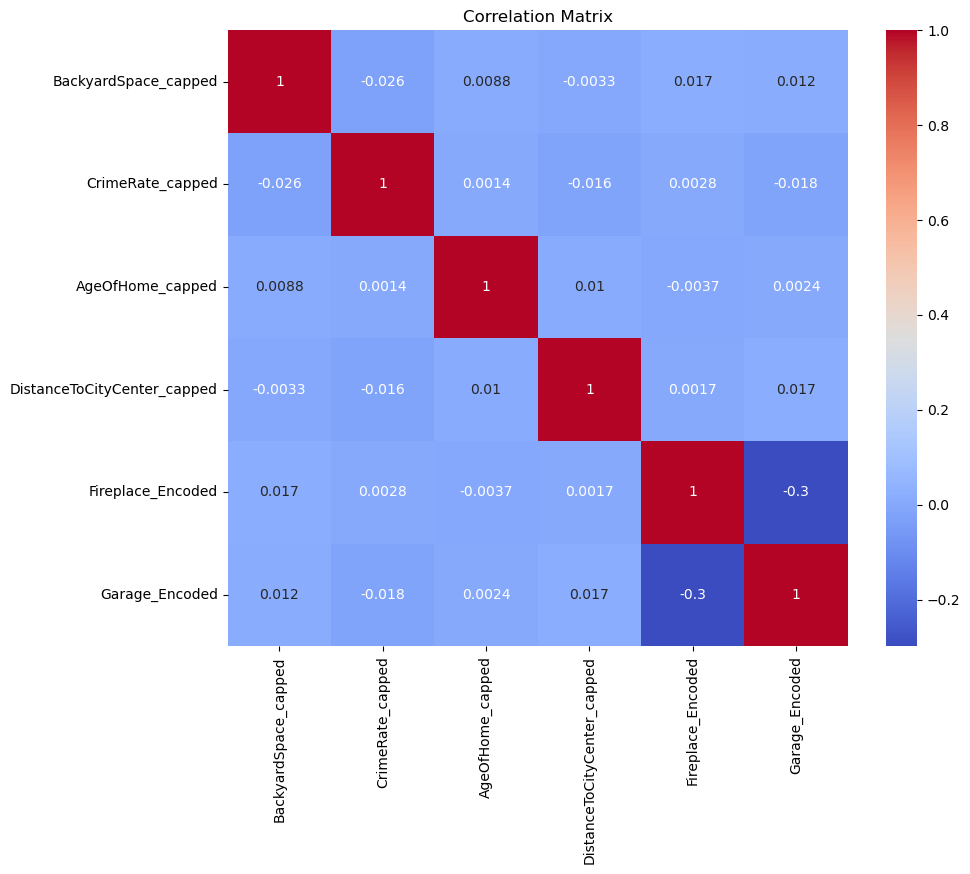

In [53]:
corr_matrix = train_X.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [54]:
## move to wrapper methods of elimination 

In [55]:
# BACKWARD ELIMINATION 

p_limit = 0.05

remaining_predictors = list(train_X.columns)
elimination_results = []
while True:
    
    formula = 'Price_capped ~ ' + ' + '.join(remaining_predictors)
    model = smf.ols(
        formula=formula,
        data=train_df
    ).fit()
    
    pvalues = model.pvalues.drop('Intercept')

    worst_p = pvalues.max()

    worst_feature = pvalues.idxmax()

    elimination_results.append({
        'remaining_variables': remaining_predictors.copy(),
        'adj_r2': model.rsquared_adj,
        'aic': model.aic,
        'bic': model.bic,
        'removed_variable': worst_feature,
        'worst_pvalue': worst_p
    })
    
    if worst_p < p_limit:
        break

    print(f"Removing {worst_feature} (p-value = {worst_p:.4f})")

    remaining_predictors.remove(worst_feature)
    
    optimized_formula = (
    'Price_capped ~ ' +
    ' + '.join(remaining_predictors)
)

optimized_model = smf.ols(
    formula=optimized_formula,
    data=train_df
).fit()

Removing Garage_Encoded (p-value = 0.9681)
Removing Fireplace_Encoded (p-value = 0.4687)


In [56]:
#check results of that backwards elimination

In [57]:
final_X = train_df[remaining_predictors]

vif_data = pd.DataFrame()
vif_data["Feature"] = final_X.columns

vif_data["VIF"] = [
    variance_inflation_factor(final_X.values, i)
    for i in range(final_X.shape[1])
]

print(vif_data)

                       Feature       VIF
0         BackyardSpace_capped  2.894089
1             CrimeRate_capped  2.826771
2             AgeOfHome_capped  2.015013
3  DistanceToCityCenter_capped  2.006069


In [58]:
print("\nFINAL SELECTED VARIABLES:")

print(remaining_predictors)

print("\nOPTIMIZED MODEL SUMMARY:")

print(optimized_model.summary())


FINAL SELECTED VARIABLES:
['BackyardSpace_capped', 'CrimeRate_capped', 'AgeOfHome_capped', 'DistanceToCityCenter_capped']

OPTIMIZED MODEL SUMMARY:
                            OLS Regression Results                            
Dep. Variable:           Price_capped   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     1014.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:58:58   Log-Likelihood:                -94823.
No. Observations:                7200   AIC:                         1.897e+05
Df Residuals:                    7195   BIC:                         1.897e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t 

# validate model

In [59]:
##redefine test subset on optimized columns and run algorith on test dataset
test_df = test_X[['BackyardSpace_capped', 'CrimeRate_capped', 'AgeOfHome_capped', 'DistanceToCityCenter_capped']].copy()

test_df['Price_capped'] = test_y

In [60]:
predictors_test = test_df.columns.drop('Price_capped')

formula_test = 'Price_capped ~ ' + ' + '.join(predictors_test)

print(formula_test)

Price_capped ~ BackyardSpace_capped + CrimeRate_capped + AgeOfHome_capped + DistanceToCityCenter_capped


In [61]:
housing_lm_test = smf.ols(
    formula=formula_test,
    data=test_df
).fit()
print(housing_lm_test.summary())

                            OLS Regression Results                            
Dep. Variable:           Price_capped   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     254.4
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          2.80e-173
Time:                        22:00:24   Log-Likelihood:                -23697.
No. Observations:                1800   AIC:                         4.740e+04
Df Residuals:                    1795   BIC:                         4.743e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [62]:
predictions2 = optimized_model.predict(train_df)
rmse = np.sqrt(
    mean_squared_error(train_y, predictions2)
)

print("RMSE:", rmse)

RMSE: 126867.63252400701


In [63]:
predictions = optimized_model.predict(test_df)
rmse = np.sqrt(
    mean_squared_error(test_y, predictions)
)

print("RMSE:", rmse)

RMSE: 126420.833380789


In [64]:
## test multicollinieartiy of final test set
test_df2 = test_df.drop(columns='Price_capped').copy()
vif_data = pd.DataFrame()

vif_data["Feature"] = test_df2.columns

vif_data["VIF"] = [
    variance_inflation_factor(test_df2.values, i)
    for i in range(test_df2.shape[1])
]

print(vif_data)

                       Feature       VIF
0         BackyardSpace_capped  2.838111
1             CrimeRate_capped  2.908466
2             AgeOfHome_capped  2.033788
3  DistanceToCityCenter_capped  1.993964


# Visualize accuracy of results

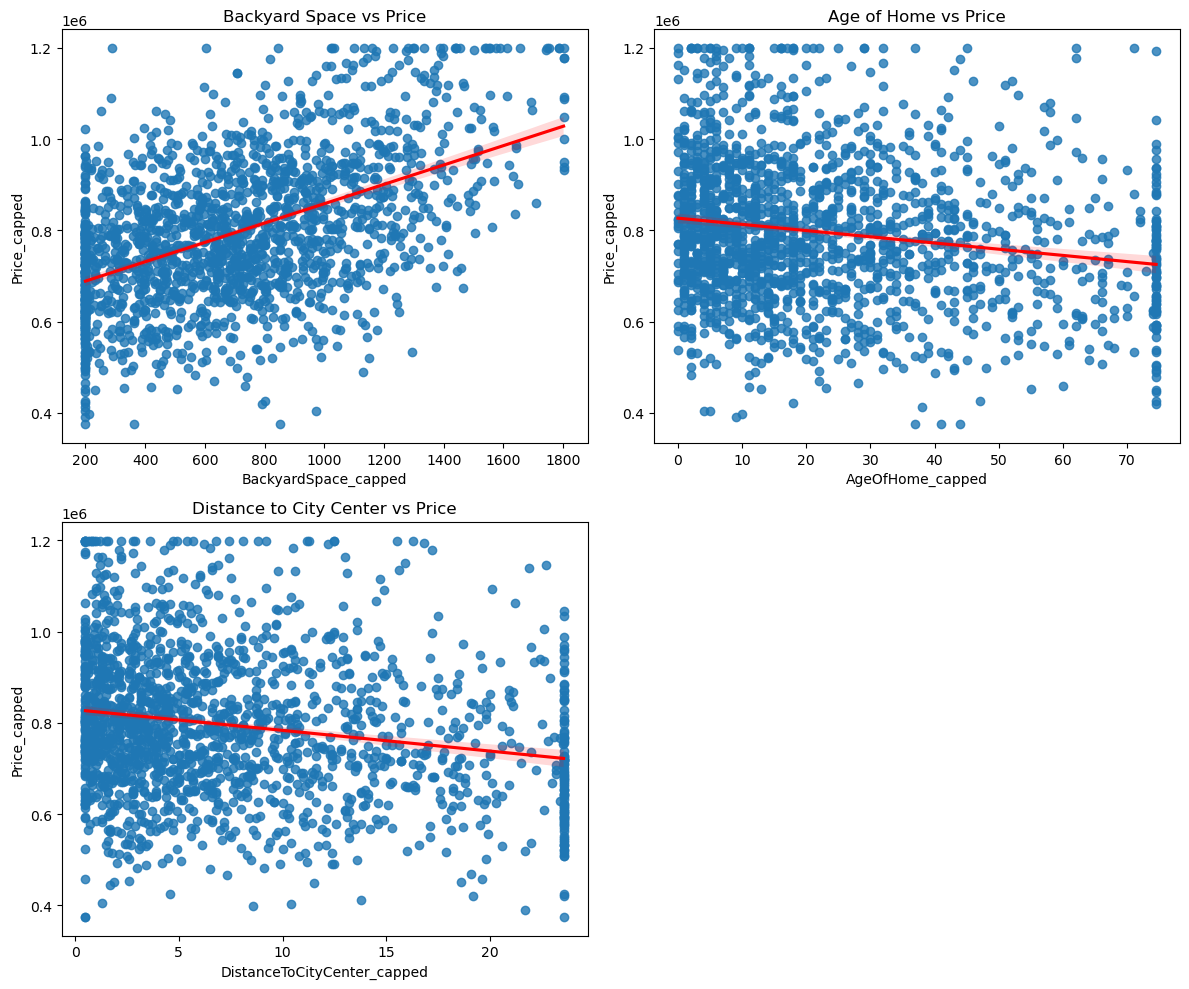

In [65]:
#visualize linearity
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.regplot(
    x='BackyardSpace_capped',
    y='Price_capped',
    data=test_df,
    line_kws={'color':'red'}
)
plt.title('Backyard Space vs Price')

plt.subplot(2,2,2)
sns.regplot(
    x='AgeOfHome_capped',
    y='Price_capped',
    data=test_df,
    line_kws={'color':'red'}
)
plt.title('Age of Home vs Price')

plt.subplot(2,2,3)
sns.regplot(
    x='DistanceToCityCenter_capped',
    y='Price_capped',
    data=test_df,
    line_kws={'color':'red'}
)
plt.title('Distance to City Center vs Price')


plt.tight_layout()
plt.show()

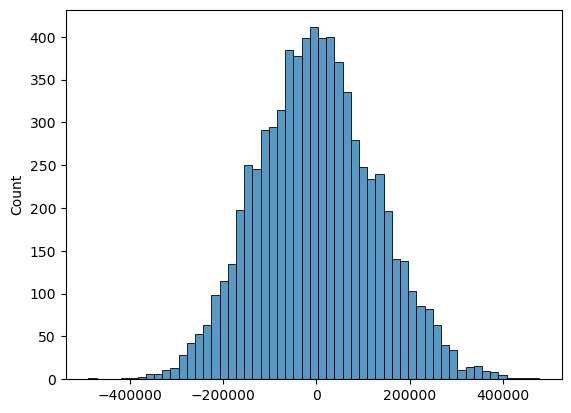

In [66]:
#residuals distribution
residuals = model.resid
sns.histplot(residuals)
plt.show()

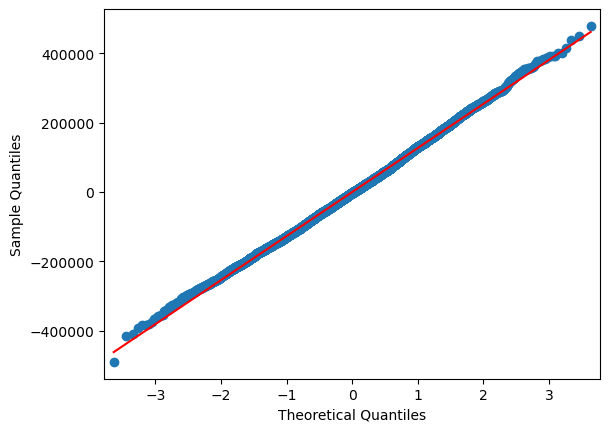

In [67]:
sm.qqplot(residuals,line='s')
plt.show()

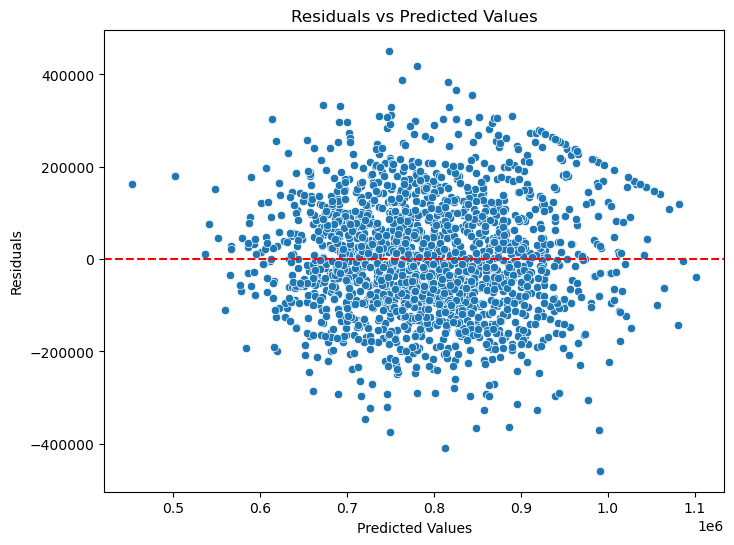

In [68]:
predictions = optimized_model.predict(test_df)
residuals = test_y - predictions
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()